# SSD 条带坐标顶点模型：独立加载与评估

**功能**：加载 `Vertex/Vertex_output/VertexMLP.pt`，用 `Vertex/Processd_test.root/tree` 中匹配的 Cluster/Recoil 条带坐标预测世界坐标顶点，并与真实 VertexX/Y/Z 比较。

**方法**：完整模型及预处理加载 → uproot / awkward 读取 11 个输入和 3 个标签 → NumPy/PyTorch float64 → 训练集参数归一化 → eval/no_grad 推理 → 输出反归一化到 mm → 逐坐标及三维误差评估。

**注意事项**：先调用同目录 PreProcess.C，一次处理 `EnergyLoss/alphap.root` 和 `alphap_test.root`，再执行 Vertex.ipynb 保存模型，最后执行本 Notebook。Cluster 用世界条带坐标，Recoil 用局域条带坐标，标签和预测均为世界坐标。左右配对和固定几何须与训练相同，真实顶点只用于评估，不进入输入；不重算归一化参数、不训练网络。仅加载自己生成的可信完整模型。模型和数据路径支持从 MachineLearning 或 Vertex 目录启动。

依赖：uproot、awkward、numpy、torch、matplotlib。CUDA 可用时使用 CUDA，否则使用 CPU，保持 float64。所有指标使用完整测试集合，残差直方图显示 [-20,20] mm。本文件交付时未执行单元；加载结构沿用用户指定的 EnergyLoss/SSD/EnergyLossEvaluation.ipynb。

## 1. 输入与设备

**事件对齐与传统比较**：`EventID` 保持 int64，只作为文件内关联键，不作为模型特征。导出 `Vertex_output/VertexMLP_test.root`，含 EventID、真实 VertexX/Y/Z 和 MLPVertexX/Y/Z。末尾单元若找到 `Tradition_test.root`，按 EventID 取交集并核对真实标签；传统输出只含成功事件，报告交集及未匹配数量，在同一批交集事件上比较两种方法。本 Notebook 导出完整独立测试文件的预测。 两个输入文件的 ID 不混用，输入更新后须重新生成相应传统与预测结果。导出会覆盖同名输出。


In [1]:
# 功能：配置顶点模型评估；方法：统一路径与 float64；注意事项：全部位置单位 mm，使用已训练模型。
from pathlib import Path

import awkward as ak
import numpy as np
import torch
import uproot
import matplotlib.pyplot as plt

VERTEX_DIR = Path.cwd() if Path.cwd().name == "Vertex" else Path.cwd() / "Vertex"
ROOT_PATH = VERTEX_DIR / "Processd_test.root"
TREE_NAME = "tree"
MODEL_PATH = VERTEX_DIR / "Vertex_output" / "VertexMLP.pt"
DTYPE = torch.float64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
saved = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
if saved.get("task") != "SSD_vertex_world":
    raise ValueError("请选择 Vertex.ipynb 保存的 SSD 世界顶点模型。")
model = saved["model"].to(device=device, dtype=DTYPE)
model.eval()
FEATURE_NAMES = saved["feature_names"]
TARGET_NAMES = saved["target_names"]
if TARGET_NAMES != ["VertexX", "VertexY", "VertexZ"] or len(FEATURE_NAMES) != 11:
    raise ValueError("模型输入/输出定义与 11→3 顶点流程不一致。")
if saved["coordinate_systems"] != {"ClusterSSD": "world", "RecoilSSD": "locus", "Vertex": "world"}:
    raise ValueError("模型坐标系约定不匹配。")
x_mean = np.asarray(saved["x_mean"], dtype=np.float64)
x_std = np.asarray(saved["x_std"], dtype=np.float64)
y_mean = np.asarray(saved["y_mean"], dtype=np.float64)
y_std = np.asarray(saved["y_std"], dtype=np.float64)
if x_mean.shape != (11,) or x_std.shape != (11,) or y_mean.shape != (3,) or y_std.shape != (3,):
    raise ValueError("模型归一化参数维度须与 11 个输入、3 个输出一致。")
if any(not np.all(np.isfinite(a)) for a in (x_mean, x_std, y_mean, y_std)):
    raise ValueError("归一化参数含 NaN/Inf。")
if np.any(x_std <= 0) or np.any(y_std <= 0):
    raise ValueError("归一化缩放量须大于 0。")
print(model)
print("Loaded:", MODEL_PATH.resolve())


Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=3, bias=True)
)
Loaded: /Users/yemingxin/ROOT_Exercise/MachineLearning/Vertex/Vertex_output/VertexMLP.pt


In [3]:
branches = FEATURE_NAMES + TARGET_NAMES
with uproot.open(ROOT_PATH) as root_file:
    tree = root_file[TREE_NAME]
    missing = [name for name in branches + ["EventID"] if name not in tree.keys()]
    if missing:
        raise KeyError(f"Missing branches: {missing}")
    entry_count = tree.num_entries
    arrays = tree.arrays(branches + ["EventID"], library="ak", how=dict)

event_ids = np.asarray(ak.to_numpy(arrays["EventID"]))
if event_ids.ndim != 1 or len(event_ids) != entry_count or event_ids.dtype != np.dtype("int64"):
    raise ValueError("EventID 必须是 Long64_t/int64 每事件标量；请先用新版 PreProcess.C 重新生成输入。")
if np.any(event_ids < 0) or np.unique(event_ids).size != len(event_ids):
    raise ValueError("EventID 必须在当前输入文件内非负且唯一。")
# EventID 保持 int64；不加入 float64 的11维特征及3维标签。

columns = {}
for name in branches:
    column = np.asarray(ak.to_numpy(arrays[name]), dtype=np.float64)
    if column.ndim != 1 or len(column) != entry_count:
        raise ValueError(f"{name} 必须是每事件一个标量，实际 shape={column.shape}")
    if np.any(~np.isfinite(column) | (column == -999.0)):
        raise ValueError(f"{name} contains NaN/Inf or -999.")
    columns[name] = column
X = np.column_stack([columns[name] for name in FEATURE_NAMES]).astype(np.float64)
y = np.column_stack([columns[name] for name in TARGET_NAMES]).astype(np.float64)
if entry_count == 0:
    raise ValueError("测试树没有事件。")
print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)


X: (1786, 11) float64
y: (1786, 3) float64


## 2. 归一化、预测和恢复世界坐标
使用保存的特征顺序和训练集归一化参数，直接调用加载的模型；三维输出通过保存的 y_std/y_mean 恢复到 mm。真实标签只用于误差评估，不作为模型输入。


In [4]:
X_scaled = (X - x_mean) / x_std
X_tensor = torch.from_numpy(np.ascontiguousarray(X_scaled, dtype=np.float64)).to(device=device, dtype=DTYPE)
model.eval()
with torch.no_grad():
    pred_scaled = model(X_tensor).cpu().numpy()
pred = pred_scaled * y_std + y_mean
if pred.shape != y.shape or not np.all(np.isfinite(pred)):
    raise RuntimeError("预测顶点维度不一致或包含 NaN/Inf。")
y_true = y
residual = pred - y_true
print("Predicted events:", len(pred))
print("EventID true XYZ world (mm)           predicted XYZ world (mm)       residual XYZ (mm)")
for i in range(min(10, len(pred))):
    print(f"{event_ids[i]:7d}   {y_true[i]}   {pred[i]}   {residual[i]}")


Predicted events: 1786
EventID true XYZ world (mm)           predicted XYZ world (mm)       residual XYZ (mm)
    373   [ -5.31909654  -0.75909708 -40.70344736]   [ -5.20134499  -1.00943591 -41.18574243]   [ 0.11775155 -0.25033883 -0.48229508]
    543   [-5.71272932 -8.97497459 17.66074484]   [-5.84955878 -8.96021437 17.44641587]   [-0.13682946  0.01476022 -0.21432897]
    775   [ -6.69648946   5.52120247 -16.9145599 ]   [ -6.72268777   5.12337733 -16.6247395 ]   [-0.02619831 -0.39782514  0.2898204 ]
    786   [-11.27445493  -4.29866207  -7.51421685]   [-11.10148584  -4.2298356   -7.74559381]   [ 0.17296909  0.06882647 -0.23137695]
    910   [-9.54942116 -8.36946966  8.42150931]   [-9.51500665 -8.62032958  8.05831627]   [ 0.03441451 -0.25085992 -0.36319304]
    960   [ -0.92159445   3.84281629 -24.05829086]   [ -0.71869404   3.4826711  -23.72431302]   [ 0.20290041 -0.36014519  0.33397784]
   1103   [-1.12008031 -3.57812642 -3.06681595]   [-1.02932883 -3.60508632 -2.80523334]   [ 0.0907

Evaluated events: 1786
VertexX
  MSE_mm2                 : 0.0583963
  RMSE_mm                 : 0.241653
  MAE_mm                  : 0.184498
  R2                      : 0.998743
  Bias_mm                 : 0.00408559
  ResidualStd_mm          : 0.241619
  Central68HalfWidth_mm   : 0.227876
VertexY
  MSE_mm2                 : 0.0679308
  RMSE_mm                 : 0.260635
  MAE_mm                  : 0.200328
  R2                      : 0.997657
  Bias_mm                 : -0.00780693
  ResidualStd_mm          : 0.260518
  Central68HalfWidth_mm   : 0.247681
VertexZ
  MSE_mm2                 : 0.0611461
  RMSE_mm                 : 0.247277
  MAE_mm                  : 0.184018
  R2                      : 0.999839
  Bias_mm                 : -0.00305198
  ResidualStd_mm          : 0.247258
  Central68HalfWidth_mm   : 0.212278
3D world-position error:
  MeanDistance_mm         : 0.380043
  RMSEDistance_mm         : 0.432982
  Q68Distance_mm          : 0.433802
  Q95Distance_mm          : 0

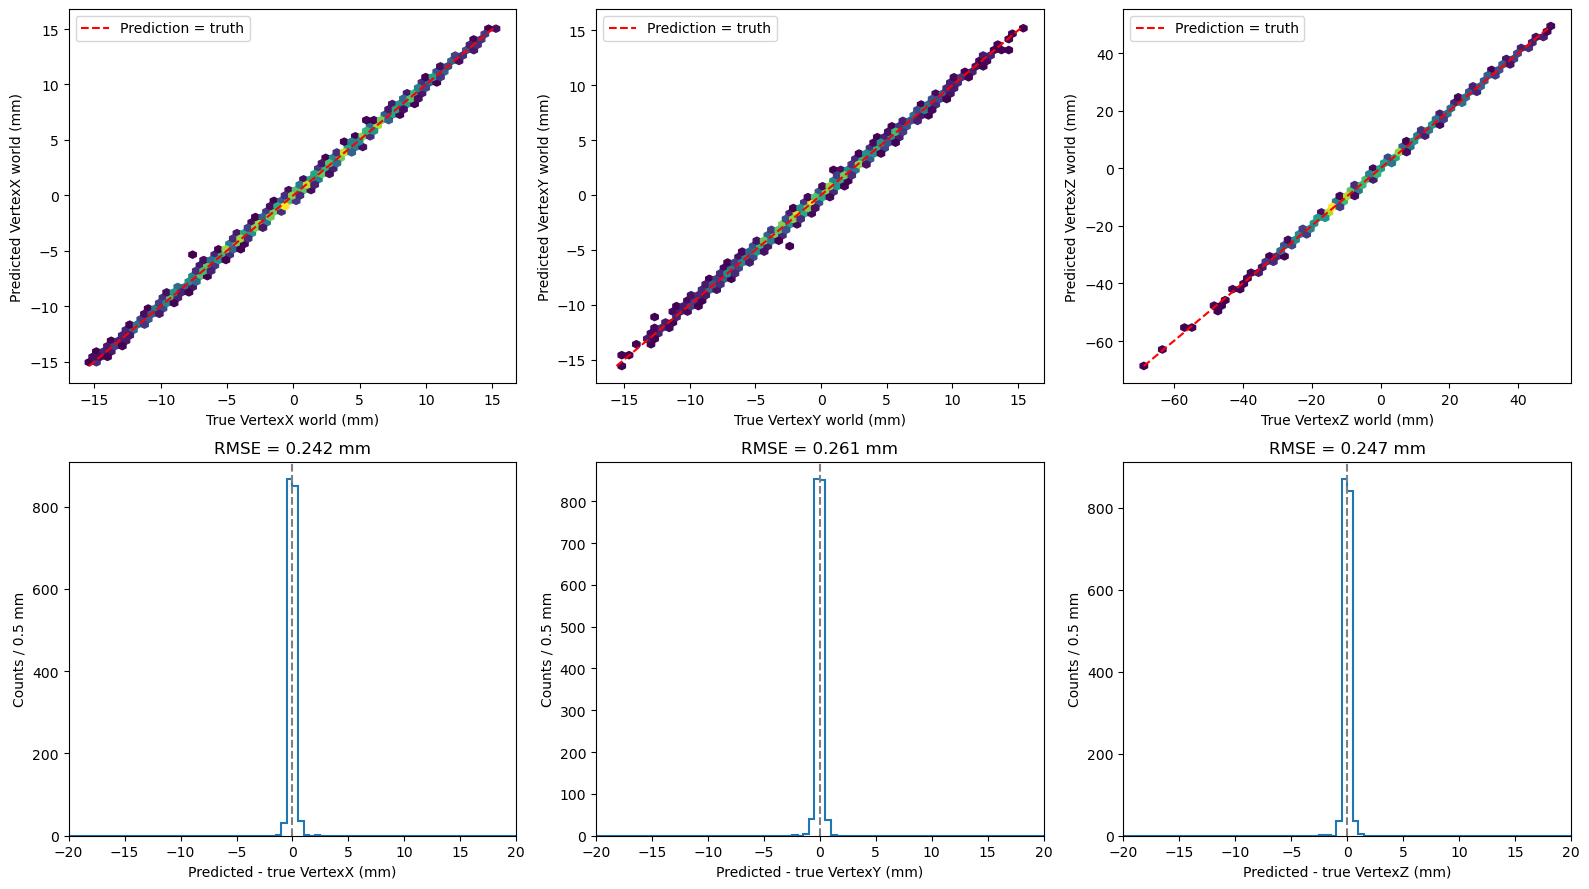

In [5]:
def vertex_metrics(truth, prediction):
    difference = prediction - truth
    rows = {}
    for axis, name in enumerate(TARGET_NAMES):
        r = difference[:, axis]
        mse = float(np.mean(r ** 2))
        ss_tot = float(np.sum((truth[:, axis] - truth[:, axis].mean()) ** 2))
        q16, q84 = np.quantile(r, [0.16, 0.84])
        rows[name] = {
            "MSE_mm2": mse,
            "RMSE_mm": float(np.sqrt(mse)),
            "MAE_mm": float(np.mean(np.abs(r))),
            "R2": 1.0 - float(np.sum(r ** 2)) / ss_tot if ss_tot > 0 else np.nan,
            "Bias_mm": float(r.mean()),
            "ResidualStd_mm": float(r.std()),
            "Central68HalfWidth_mm": float((q84 - q16) / 2.0),
        }
    distance = np.linalg.norm(difference, axis=1)
    distance_metrics = {
        "MeanDistance_mm": float(distance.mean()),
        "RMSEDistance_mm": float(np.sqrt(np.mean(distance ** 2))),
        "Q68Distance_mm": float(np.quantile(distance, 0.68)),
        "Q95Distance_mm": float(np.quantile(distance, 0.95)),
    }
    return rows, distance_metrics

metrics, distance_metrics = vertex_metrics(y_true, pred)
print(f"Evaluated events: {len(y_true)}")
for name, values in metrics.items():
    print(name)
    for key, value in values.items():
        print(f"  {key:24s}: {value:.6g}")
print("3D world-position error:")
for key, value in distance_metrics.items():
    print(f"  {key:24s}: {value:.6g}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
residual_bins = np.arange(-20.0, 20.0 + 0.5, 0.5)
for axis, name in enumerate(TARGET_NAMES):
    ax = axes[0, axis]
    ax.hexbin(y_true[:, axis], pred[:, axis], gridsize=55, mincnt=1, cmap="viridis")
    lo = min(y_true[:, axis].min(), pred[:, axis].min())
    hi = max(y_true[:, axis].max(), pred[:, axis].max())
    ax.plot([lo, hi], [lo, hi], "r--", label="Prediction = truth")
    ax.set_xlabel(f"True {name} world (mm)")
    ax.set_ylabel(f"Predicted {name} world (mm)")
    ax.legend()
    ax = axes[1, axis]
    _, bin_edges, _ = ax.hist(residual[:, axis], bins=residual_bins, histtype="step", linewidth=1.5)
    ax.set_xlim(-20.0, 20.0)
    ax.set_xlabel(f"Predicted - true {name} (mm)")
    ax.set_ylabel(f"Counts / {bin_edges[1] - bin_edges[0]:.3g} mm")
    ax.axvline(0.0, color="gray", linestyle="--")
    ax.set_title(f"RMSE = {metrics[name]['RMSE_mm']:.3g} mm")
fig.tight_layout()
plt.show()


## EventID 预测导出与传统方法对比

先运行前面的预测和误差评估单元。Tradition.C 独立遍历原始文件且只保存成功事件，传统结果存在时按 EventID 取交集比较。未匹配事件可能被筛除或几何重建失败，不能仅凭缺失 ID 区分原因。


MLP评估事件=1786，传统成功事件=1786，共同事件=1786，未匹配传统结果=0
VertexX MLP: RMSE=0.241653 mm，显示范围外事件=0
VertexX Tradition: RMSE=0.276451 mm，显示范围外事件=0
VertexY MLP: RMSE=0.260635 mm，显示范围外事件=0
VertexY Tradition: RMSE=0.283365 mm，显示范围外事件=0
VertexZ MLP: RMSE=0.247277 mm，显示范围外事件=0
VertexZ Tradition: RMSE=0.27962 mm，显示范围外事件=0


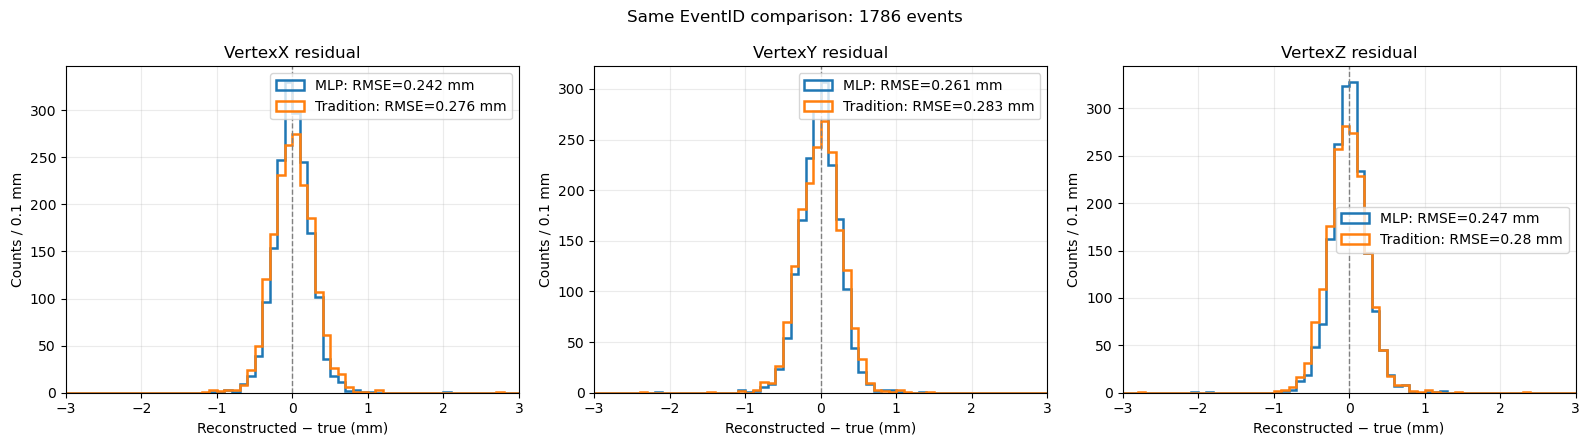

In [6]:
# 功能：按 EventID 对齐共同事件，叠加绘制 MLP 和传统方法的世界坐标 XYZ 残差。
# 方法：两种方法使用同一批事件；残差为重建值减真值。
# 注意事项：只在 Notebook 显示，不写本地文件；显示范围 [-3, 3] mm，
#           bin 宽度 0.1 mm，横轴主刻度间隔 1 mm；RMSE 使用全部共同事件。

from matplotlib.ticker import MultipleLocator

ml_event_ids = event_ids
tradition_path = VERTEX_DIR / "Tradition_test.root"

if not tradition_path.exists():
    raise FileNotFoundError(f"请先生成传统重建结果：{tradition_path}")

comparison_branches = (
    ["EventID"]
    + TARGET_NAMES
    + ["Tradition" + name for name in TARGET_NAMES]
)
with uproot.open(tradition_path) as tradition_file:
    tradition_arrays = tradition_file["tree"].arrays(
        comparison_branches, library="np"
    )

traditional_ids = tradition_arrays["EventID"]
for label, ids in [("MLP", ml_event_ids), ("Tradition", traditional_ids)]:
    if ids.ndim != 1 or ids.dtype != np.dtype("int64"):
        raise ValueError(f"{label} EventID 必须是 int64 标量。")
    if np.any(ids < 0) or np.unique(ids).size != len(ids):
        raise ValueError(f"{label} EventID 无效或重复。")

if (
    y_true.ndim != 2
    or y_true.shape[1] != 3
    or len(ml_event_ids) != len(y_true)
    or pred.shape != y_true.shape
):
    raise ValueError("MLP 的 EventID、真实顶点与预测顶点不对应。")

lookup = {int(event_id): i for i, event_id in enumerate(traditional_ids)}
ml_rows = np.array(
    [
        i for i, event_id in enumerate(ml_event_ids)
        if int(event_id) in lookup
    ],
    dtype=np.int64,
)
tradition_rows = np.array(
    [lookup[int(ml_event_ids[i])] for i in ml_rows],
    dtype=np.int64,
)

print(
    f"MLP评估事件={len(ml_event_ids)}，"
    f"传统成功事件={len(traditional_ids)}，"
    f"共同事件={len(ml_rows)}，"
    f"未匹配传统结果={len(ml_event_ids) - len(ml_rows)}"
)

if len(ml_rows) == 0:
    raise ValueError("没有共同 EventID，请确认结果来自同一原始文件。")

common_truth = y_true[ml_rows]
ml_prediction = pred[ml_rows]
traditional_truth = np.column_stack([
    tradition_arrays[name][tradition_rows]
    for name in TARGET_NAMES
])
traditional_prediction = np.column_stack([
    tradition_arrays["Tradition" + name][tradition_rows]
    for name in TARGET_NAMES
])

for values in [
    common_truth, traditional_truth,
    ml_prediction, traditional_prediction,
]:
    if np.any(~np.isfinite(values)) or np.any(values == -999.0):
        raise ValueError("共同事件中存在无效顶点。")

if not np.allclose(
    traditional_truth, common_truth, rtol=0.0, atol=1e-9
):
    raise ValueError("同一 EventID 的真实顶点不同，请检查输入来源。")

ml_residual = ml_prediction - common_truth
traditional_residual = traditional_prediction - common_truth

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
bins = np.linspace(-3.0, 3.0, 61)

for axis, ax in enumerate(axes):
    for label, residuals, color in [
        ("MLP", ml_residual, "tab:blue"),
        ("Tradition", traditional_residual, "tab:orange"),
    ]:
        values = residuals[:, axis]
        rmse = np.sqrt(np.mean(values**2))
        outside = np.count_nonzero((values < -3.0) | (values > 3.0))
        print(
            f"{TARGET_NAMES[axis]} {label}: "
            f"RMSE={rmse:.6g} mm，显示范围外事件={outside}"
        )
        ax.hist(
            values,
            bins=bins,
            histtype="step",
            linewidth=1.8,
            color=color,
            label=f"{label}: RMSE={rmse:.3g} mm",
        )

    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(-3.0, 3.0)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))
    ax.set_title(f"{TARGET_NAMES[axis]} residual")
    ax.set_xlabel("Reconstructed − true (mm)")
    ax.set_ylabel("Counts / 0.1 mm")
    ax.legend()
    ax.grid(alpha=0.25)

fig.suptitle(f"Same EventID comparison: {len(ml_rows)} events")
fig.tight_layout()
plt.show()
